In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import open3d as o3d
from scipy.spatial.transform import Rotation as R 
import os 
import glob 
import pandas as pd 
from tqdm import tqdm
from scipy.ndimage import median_filter

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
color_intrinsics = {
    'width': 1280,
    'height': 720,
    'fx': 643.90087890625,
    'fy': 643.1365356445312,
    'cx': 650.2113037109375,
    'cy': 355.79559326171875,
    'model': "distortion.inverse_brown_conrady",
    'coeffs': [-0.05658450722694397, 0.06544225662946701,-0.0008694113348610699, 0.00016751799557823688,-0.020957745611667633]
}

depth_intrinsics = {
    'width': 1280,
    'height': 720,
    'fx': 650.0616455078125,
    'fy': 650.0616455078125,
    'cx': 649.5928955078125,
    'cy': 360.9415588378906,
    'model': "distortion.brown_conrady",
    'coeffs': [0.0, 0.0, 0.0, 0.0, 0.0]
}

ROI_X = 550
ROI_Y = 150
ROI_WIDTH = 300
ROI_HEIGHT = 330

roi = (ROI_X, ROI_Y, ROI_WIDTH, ROI_HEIGHT )


In [3]:
# 1. Đường dẫn đến thư mục chứa các file mask .npy
MASK_DIR = "masks_npy"

# =============================================================================
# HÀM CHÍNH (MAIN SCRIPT) - ĐÃ CẬP NHẬT LOGIC LOẠI BỎ
# =============================================================================

def get_masks_in_roi(roi):
    ROI_X, ROI_Y, ROI_W, ROI_H = roi
    results_list = []
    print(f"Bắt đầu quét thư mục mask: {MASK_DIR}")
    
    try:
        mask_files = [f for f in os.listdir(MASK_DIR) if f.endswith('.npy')]
    except FileNotFoundError:
        print(f"LỖI: Không tìm thấy thư mục: {MASK_DIR}")
        return
    
    if not mask_files:
        print(f"LỖI: Không tìm thấy file '.npy' nào.")
        return

    print(f"Tìm thấy {len(mask_files)} file mask. Bắt đầu tính toán...")

    skipped_masks = 0  # cần khai báo trước

    for filename in tqdm(mask_files, desc="Đang xử lý"):
        try:
            mask = np.load(os.path.join(MASK_DIR, filename))
            mask_uint8 = (mask * 255).astype(np.uint8)

            M = cv2.moments(mask_uint8)
            if M["m00"] > 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                
                # --- [MỚI] 4. Kiểm tra tâm có nằm trong mask không ---
                # Đảm bảo toạ độ không vượt quá kích thước ảnh
                h, w = mask_uint8.shape
                cx = min(max(cx, 0), w - 1)
                cy = min(max(cy, 0), h - 1)

                # Nếu pixel tại (cy, cx) là nền (giá trị 0) -> LOẠI BỎ
                if mask_uint8[cy, cx] == 0:
                    skipped_masks += 1
                    continue # Bỏ qua mask này, sang mask tiếp theo

                if not (ROI_X <= cx < ROI_X + ROI_W and ROI_Y <= cy < ROI_Y + ROI_H):
                    skipped_masks += 1
                    continue

                # Tìm bounding box của mask (full-image coords)
                coords = np.argwhere(mask_uint8 > 0)  # shape (N,2) mỗi dòng (cy, cx) full-image coords
                if coords.size == 0:
                    skipped_masks += 1
                    continue
                y_min, x_min = coords.min(axis=0)
                y_max, x_max = coords.max(axis=0) + 1

                # Crop mask theo bbox (crop coordinates)
                mask_cropped = mask_uint8[y_min:y_max, x_min:x_max]

                # --- NEW: mask pixels inside the CROP but expressed in FULL-IMAGE coordinates ---
                # coords_crop are local coordinates inside the cropped mask (row,col)
                coords_crop = np.argwhere(mask_cropped > 0)  # shape (M,2): (row_in_crop, col_in_crop)
                if coords_crop.size == 0:
                    skipped_masks += 1
                    continue
                # convert crop coords -> full-image coords by adding offsets (y_min, x_min)
                full_rows = coords_crop[:, 0] + int(y_min)
                full_cols = coords_crop[:, 1] + int(x_min)
                # pack as (cy, cx) full-image coords
                mask_pixels_in_crop_full = np.stack((full_rows, full_cols), axis=1)

                # For compatibility, also keep all mask pixels (full-image) if needed
                mask_pixels_full = coords  # already full-image (cy, cx)

                results_list.append({
                    'image_name': f"{filename.split('_')[0]}.png",
                    'mask_full': mask_uint8,
                    'mask': mask_cropped,
                    '2d_x': cx,
                    '2d_y': cy,
                    'x_min': int(x_min),
                    'y_min': int(y_min),
                    'x_max': int(x_max),
                    'y_max': int(y_max),
                    # mask_pixels: only pixels inside the crop but coordinates are full-image (row, col)
                    'mask_pixels': mask_pixels_in_crop_full,
                    # optional extra field if you need the full-mask pixels as well
                    'mask_pixels_full': mask_pixels_full
                })

        except Exception as e:
            print(f"Lỗi file {filename}: {e}")

    return results_list


In [4]:
def deproject_with_inverse_model(u_distorted, v_distorted, depth_meters, intrinsics):
    fx = intrinsics['fx']; fy = intrinsics['fy']; cx = intrinsics['cx']; cy = intrinsics['cy']
    k1, k2, p1, p2, k5 = intrinsics['coeffs']
    x_distorted_normalized = (u_distorted - cx) / fx
    y_distorted_normalized = (v_distorted - cy) / fy
    r2 = x_distorted_normalized**2 + y_distorted_normalized**2; r4 = r2**2; r6 = r2**3
    radial_distortion = 1 + k1*r2 + k2*r4 + k5*r6
    tangential_distortion_x = 2*p1*x_distorted_normalized*y_distorted_normalized + p2*(r2 + 2*x_distorted_normalized**2)
    tangential_distortion_y = p1*(r2 + 2*y_distorted_normalized**2) + 2*p2*x_distorted_normalized*y_distorted_normalized
    x_undistorted_normalized = x_distorted_normalized * radial_distortion + tangential_distortion_x
    y_undistorted_normalized = y_distorted_normalized * radial_distortion + tangential_distortion_y
    z_c = depth_meters; x_c = x_undistorted_normalized * z_c; y_c = y_undistorted_normalized * z_c
    return x_c, y_c, z_c

In [7]:
def fit_plane_3d_ransac(points_3d, threshold=0.01, max_trials=100):
    if len(points_3d) < 3:
        return None
    
    best_inliers = None
    best_plane = None
    max_inliers = 0
    
    np.random.seed(42)
    
    for _ in range(max_trials):
        # Chọn ngẫu nhiên 3 điểm
        idx = np.random.choice(len(points_3d), 3, replace=False)
        p1, p2, p3 = points_3d[idx]
        
        # Tính normal vector từ 2 vectors trên plane
        v1 = p2 - p1
        v2 = p3 - p1
        normal = np.cross(v1, v2)
        
        # Kiểm tra degeneracy (3 điểm thẳng hàng)
        norm_length = np.linalg.norm(normal)
        if norm_length < 1e-6:
            continue
        
        # Normalize
        normal = normal / norm_length
        
        # Tính d: ax + by + cz + d = 0 → d = -(ax + by + cz)
        d = -np.dot(normal, p1)
        
        # Tính khoảng cách từ tất cả điểm đến plane
        # Distance = |ax + by + cz + d| / sqrt(a² + b² + c²)
        # Vì normal đã normalized nên sqrt(a² + b² + c²) = 1
        distances = np.abs(points_3d @ normal + d)
        
        # Đếm inliers
        inlier_mask = distances < threshold
        num_inliers = np.sum(inlier_mask)
        
        if num_inliers > max_inliers:
            max_inliers = num_inliers
            best_inliers = inlier_mask
            best_plane = (normal, d)
    
    if best_plane is None or max_inliers < 3:
        return None
    
    # Refine plane bằng least squares trên tất cả inliers
    inlier_points = points_3d[best_inliers]
    
    # SVD để fit plane chính xác hơn
    centroid = np.mean(inlier_points, axis=0)
    centered = inlier_points - centroid
    _, _, vh = np.linalg.svd(centered)
    
    # Normal là singular vector nhỏ nhất (hàng cuối của V^T)
    refined_normal = vh[2, :]
    refined_d = -np.dot(refined_normal, centroid)
    
    return {
        'normal': refined_normal,
        'd': refined_d,
    }

In [9]:
def preprocess_depth_image(depth_image_raw, scale=1000.0, fill_holes=True):
    Z = depth_image_raw.astype(np.float32) / scale
    valid = (Z > 0.01) & (Z < 5.0) & np.isfinite(Z)
    
    if fill_holes:
        Z_filled = median_filter(Z, size=3)
        fill_mask = (~valid) & (cv2.dilate(valid.astype(np.uint8), np.ones((3,3), np.uint8)) > 0)
        Z[fill_mask] = Z_filled[fill_mask]
    
    return Z

In [12]:
import json
Z_THRESHOLD_METERS = 0.005 
ROBOT_COORD_3D = np.array([0.6524, -0.2263, 0.9340])
OUTPUT_CSV = "Submission_3D.csv"

def process_all_masks(roi, depth_img_dir, depth_intr, colors_intr, 
                      neighbor_radius=15, plane_threshold=0.005, 
                      distance_threshold=0.01, sigma_ratio=0.5):
    print("=" * 60)
    print("BƯỚC 1: Lấy masks trong ROI")
    print("=" * 60)
    masks_data = get_masks_in_roi(roi)
    if masks_data is None or len(masks_data) == 0:
        print("Không có mask nào trong ROI!")
        return None
    print(f"✓ Tìm thấy {len(masks_data)} masks hợp lệ\n")
    print("=" * 60)
    print("BƯỚC 2: Nhóm masks theo image")
    print("=" * 60)
    masks_by_image = {}
    for mask_data in masks_data:
        img_name = mask_data['image_name']
        if img_name not in masks_by_image:
            masks_by_image[img_name] = []
        masks_by_image[img_name].append(mask_data)
    print(f"✓ Có {len(masks_by_image)} images khác nhau\n")
    print("=" * 60)
    print("BƯỚC 3: Xử lý từng image")
    print("=" * 60)
    results = []
    failed_count = 0
    total_masks = 0
    depth_meters_cache = {} 
    for img_name, masks_list in tqdm(masks_by_image.items(), desc="Processing images"):
        depth_path = os.path.join(depth_img_dir, img_name)
        if not os.path.exists(depth_path):
            print(f"\n Không tìm thấy: {depth_path}")
            failed_count += len(masks_list)
            total_masks += len(masks_list)
            continue
        depth_img_raw = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)
        if depth_img_raw is None:
            print(f"\n Không load được: {depth_path}")
            failed_count += len(masks_list)
            total_masks += len(masks_list)
            continue
        # Fill hole
        depth_meters_cache[img_name] = preprocess_depth_image(depth_img_raw, 1000.0, fill_holes=True)
        #depth_meters_cache[img_name] = adaptive_fill_holes(depth_img_raw, HOLE_FILL_BUCKETS)
        depth_meters = depth_meters_cache[img_name]

        for mask_data in masks_list:
            total_masks += 1
            try:
                center_u = int(round(mask_data['2d_x']))
                center_v = int(round(mask_data['2d_y']))

                # --- Bước A: Lấy điểm 3D trong vòng tròn pixel (neighbor_radius) từ ảnh depth ---
                h, w = depth_meters.shape
                u_min = max(0, center_u - neighbor_radius)
                u_max = min(w, center_u + neighbor_radius + 1)
                v_min = max(0, center_v - neighbor_radius)
                v_max = min(h, center_v + neighbor_radius + 1)

                uu, vv = np.meshgrid(np.arange(u_min, u_max), np.arange(v_min, v_max), indexing='xy')
                uu, vv = uu.ravel(), vv.ravel()
                circle_mask = (uu - center_u)**2 + (vv - center_v)**2 <= neighbor_radius**2
                uu, vv = uu[circle_mask], vv[circle_mask]

                if len(uu) == 0:
                    failed_count += 1
                    continue

                neigh_points = []
                for u_px, v_px in zip(uu, vv):
                    z_val = depth_meters[v_px, u_px]
                    if z_val <= 0 or not np.isfinite(z_val):
                        continue
                    x_d, y_d, z_d = deproject_with_inverse_model(u_px, v_px, z_val, colors_intr)
                    neigh_points.append([x_d, y_d, z_d])

                if len(neigh_points) < 3:
                    failed_count += 1
                    continue

                neigh_pts = np.array(neigh_points)

                # --- Bước B: Fit plane trên neighborhood points ---
                plane_result = fit_plane_3d_ransac(neigh_pts, threshold=plane_threshold)
                if plane_result is None:
                    failed_count += 1
                    continue

                normal = plane_result['normal']
                d_plane = plane_result['d']

                # --- Bước C: Deproject mask pixels (pixels inside crop) sang 3D directly ---
                mask_pixels = mask_data.get('mask_pixels', None)  # shape (M,2) of (row, col) in full-image coords
                if mask_pixels is None or mask_pixels.size == 0:
                    failed_count += 1
                    continue

                mask_pts3d = []
                mask_pts_px_dist = []  # pixel distance to center (for weighting)
                for (row_full, col_full) in mask_pixels:
                    r = int(row_full); c = int(col_full)
                    if r < 0 or r >= depth_meters.shape[0] or c < 0 or c >= depth_meters.shape[1]:
                        continue
                    z_val = depth_meters[r, c]
                    if z_val <= 0 or not np.isfinite(z_val):
                        continue
                    x3, y3, z3 = deproject_with_inverse_model(c, r, z_val, colors_intr)
                    mask_pts3d.append([x3, y3, z3])
                    # pixel-space distance to centroid (use euclidean on pixels)
                    dist_px = np.sqrt((c - center_u)**2 + (r - center_v)**2)
                    mask_pts_px_dist.append(dist_px)

                if len(mask_pts3d) == 0:
                    failed_count += 1
                    continue

                mask_pts3d = np.array(mask_pts3d)
                mask_pts_px_dist = np.array(mask_pts_px_dist)

                # --- Bước D: Lọc mask points theo khoảng cách đến plane ---
                dists = np.abs(mask_pts3d @ normal + d_plane)
                near_mask = dists <= distance_threshold
                if not np.any(near_mask):
                    failed_count += 1
                    continue

                selected_pts = mask_pts3d[near_mask]
                selected_dists_px = mask_pts_px_dist[near_mask]

                # Compute weighted centroid of selected points (weights based on pixel distance)
                sigma = max(1e-6, neighbor_radius * sigma_ratio)
                weights = np.exp(-0.5 * (selected_dists_px / sigma)**2)
                weight_total = np.sum(weights)
                if weight_total == 0:
                    failed_count += 1
                    continue
                weighted_sum = np.sum(selected_pts * weights[:, None], axis=0)
                new_centroid = weighted_sum / weight_total


                results.append({
                    'image_filename': mask_data['image_name'],
                    '2d_x': mask_data['2d_x'],
                    '2d_y': mask_data['2d_y'],
                    'x': float(new_centroid[0]),
                    'y': float(new_centroid[1]),
                    'z': float(new_centroid[2]),
                    'normal_plane': np.array2string(normal, separator=','),
                    'd_plane': d_plane,
                    'selected points': json.dumps(selected_pts.tolist())
                })

            except Exception as e:
                print(f"\nLỗi mask trong {img_name}: {e}")
                failed_count += 1
                continue

    df_all = pd.DataFrame(results)
    if df_all.empty:
        return
    print("Đang lọc kết quả cuối cùng...")
    df_all['min_z'] = df_all.groupby('image_filename')['z'].transform('min')
    cands = df_all[df_all['z'] <= (df_all['min_z'] + Z_THRESHOLD_METERS)].copy()
    cands['dist'] = np.linalg.norm(cands[['x','y','z']].values - ROBOT_COORD_3D, axis=1)
    final_df = cands.sort_values(['dist'], ascending=False).drop_duplicates('image_filename')
    final_df['image_filename'] = 'image_' + final_df['image_filename'].str.replace('image_', '', regex=False)
    final_df[['image_filename', 'x', 'y', 'z', 'normal_plane', 'd_plane', 'selected points']].to_csv(OUTPUT_CSV, index=False, float_format='%.3f')
    print(f"Hoàn tất! Đã lưu vào {OUTPUT_CSV}")


In [13]:
DEPTH_IMAGE_DIR = "train/depth"
process_all_masks(
        roi=roi,
        depth_img_dir=DEPTH_IMAGE_DIR,
        depth_intr=depth_intrinsics,
        colors_intr=color_intrinsics,
        neighbor_radius=5,        # Bán kính fit plane
        plane_threshold=0.005,    
        distance_threshold=0.005    
    )
    

BƯỚC 1: Lấy masks trong ROI
Bắt đầu quét thư mục mask: masks_npy
Tìm thấy 1248 file mask. Bắt đầu tính toán...


Đang xử lý: 100%|██████████| 1248/1248 [00:10<00:00, 123.04it/s]


✓ Tìm thấy 694 masks hợp lệ

BƯỚC 2: Nhóm masks theo image
✓ Có 369 images khác nhau

BƯỚC 3: Xử lý từng image


Processing images: 100%|██████████| 369/369 [05:14<00:00,  1.17it/s]


Đang lọc kết quả cuối cùng...
Hoàn tất! Đã lưu vào Submission_3D.csv


In [14]:
import pandas as pd
import numpy as np
import os

# --- 1. Định nghĩa Tên tệp và Hằng số ---
PREDICT_CSV = "Submission_3D.csv"
GT_CSV = "public_train.csv"

# Tên file output mới để lưu kết quả so sánh
OUTPUT_CSV_PATH = "comparison_metrics_normalized.csv"

# [THÊM MỚI] Ngưỡng sai số hợp lệ (0.05 mét = 5cm)
VALIDITY_THRESHOLD = 0.05

# --- 2. Hàm tính toán ---
def calculate_metrics():
    """
    Tải file dự đoán và file ground truth, so sánh,
    tính MCE chuẩn hóa, lưu kết quả và in ra các chỉ số trung bình.
    """
    
    # --- 3. Tải dữ liệu ---
    try:
        cols_to_use = ['image_filename', 'x', 'y', 'z']
        df_predict = pd.read_csv(PREDICT_CSV, usecols=cols_to_use)
        df_gt = pd.read_csv(GT_CSV, usecols=cols_to_use)
        
    except FileNotFoundError as e:
        print(f"LỖI: Không tìm thấy tệp: {e.filename}")
        return
    except ValueError as e:
        print(f"LỖI: Tệp CSV có thể thiếu cột. {e}")
        print(f"Hãy đảm bảo cả hai tệp đều có cột: {cols_to_use}")
        return
    except Exception as e:
        print(f"LỖI khi đọc CSV: {e}")
        return

    print(f"Đã tải {len(df_predict)} dự đoán từ: {os.path.basename(PREDICT_CSV)}")
    print(f"Đã tải {len(df_gt)} ground truth từ: {os.path.basename(GT_CSV)}")

    # --- 4. Gộp (Merge) hai DataFrame ---
    df_merged = pd.merge(
        df_predict, 
        df_gt, 
        on='image_filename', 
        suffixes=('_pred', '_gt')
    )
    
    if df_merged.empty:
        print("LỖI: Không có image_filename nào trùng khớp giữa hai tệp.")
        return

    print(f"Tìm thấy {len(df_merged)} ảnh trùng khớp để so sánh.")

    # --- 5. Tính toán Sai số (Error) ---
    
    # 5a. Tính sai số (deviation) cho từng trục (giữ nguyên)
    df_merged['x_error'] = df_merged['x_pred'] - df_merged['x_gt']
    df_merged['y_error'] = df_merged['y_pred'] - df_merged['y_gt']
    df_merged['z_error'] = df_merged['z_pred'] - df_merged['z_gt']

    # 5b. Tính khoảng cách Euclidean 3D thô (để làm cơ sở)
    pred_coords = df_merged[['x_pred', 'y_pred', 'z_pred']].to_numpy()
    gt_coords = df_merged[['x_gt', 'y_gt', 'z_gt']].to_numpy()
    df_merged['mce_distance'] = np.linalg.norm(pred_coords - gt_coords, axis=1)

    # 5c. [LOGIC MỚI] Tính MCE chuẩn hóa và giới hạn
    # Chia sai số thô cho ngưỡng, sau đó giới hạn giá trị tối đa là 1.0
    df_merged['normalized_mce'] = (df_merged['mce_distance'] / VALIDITY_THRESHOLD).clip(upper=1.0)


    # --- 6. Lưu file CSV kết quả chi tiết ---
    
    # [SỬA] Thêm cột mới vào file output
    output_columns = [
        'image_filename', 
        'x_pred', 'x_gt', 'x_error',
        'y_pred', 'y_gt', 'y_error',
        'z_pred', 'z_gt', 'z_error',
        'mce_distance',     # Sai số thô (mét)
        'normalized_mce'    # Sai số đã chuẩn hóa và giới hạn
    ]
    
    df_results = df_merged[output_columns]
    
    try:
        df_results.to_csv(OUTPUT_CSV_PATH, index=False, float_format='%.3f')
        print(f"\nĐã lưu kết quả so sánh chi tiết vào: {OUTPUT_CSV_PATH}")
    except Exception as e:
        print(f"\nLỖI: Không thể lưu file CSV: {e}")

    # --- 7. Tính toán và In ra các chỉ số trung bình đã cập nhật ---
    
    # [SỬA] Chỉ số chính là MCE chuẩn hóa trung bình
    mean_normalized_mce = df_merged['normalized_mce'].mean()
    
    # [THÊM MỚI] Tính tỷ lệ hợp lệ
    accuracy_rate = (df_merged['mce_distance'] < VALIDITY_THRESHOLD).mean() * 100
    
    # Giữ lại các chỉ số thô để tham khảo
    mean_raw_mce = df_merged['mce_distance'].mean()
    mean_x_deviation = df_merged['x_error'].mean()
    mean_y_deviation = df_merged['y_error'].mean()
    mean_z_deviation = df_merged['z_error'].mean()
    
    print("\n" + "="*50)
    print("--- 🏆 CHỈ SỐ CHUẨN HÓA (Normalized MCE) ---")
    print(f"Điểm MCE chuẩn hóa trung bình: {mean_normalized_mce:.3f} (0 = hoàn hảo, 1 = sai số lớn)")
    print(f"Tỷ lệ hợp lệ (sai số < {VALIDITY_THRESHOLD*1000:.0f}mm): {accuracy_rate:.2f}%")
    print("="*50)
    
    print("\n--- 📊 CHỈ SỐ THÔ (Để tham khảo) ---")
    print(f"MCE trung bình (Khoảng cách 3D thô): {mean_raw_mce:.3f} mét")
    print(f"Độ lệch X trung bình (pred - gt): {mean_x_deviation:.3f} mét")
    print(f"Độ lệch Y trung bình (pred - gt): {mean_y_deviation:.3f} mét")
    print(f"Độ lệch Z trung bình (pred - gt): {mean_z_deviation:.3f} mét")


# --- Chạy hàm chính ---
if __name__ == "__main__":
    calculate_metrics()

Đã tải 369 dự đoán từ: Submission_3D.csv
Đã tải 350 ground truth từ: public_train.csv
Tìm thấy 349 ảnh trùng khớp để so sánh.

Đã lưu kết quả so sánh chi tiết vào: comparison_metrics_normalized.csv

--- 🏆 CHỈ SỐ CHUẨN HÓA (Normalized MCE) ---
Điểm MCE chuẩn hóa trung bình: 0.185 (0 = hoàn hảo, 1 = sai số lớn)
Tỷ lệ hợp lệ (sai số < 50mm): 97.13%

--- 📊 CHỈ SỐ THÔ (Để tham khảo) ---
MCE trung bình (Khoảng cách 3D thô): 0.013 mét
Độ lệch X trung bình (pred - gt): -0.003 mét
Độ lệch Y trung bình (pred - gt): 0.000 mét
Độ lệch Z trung bình (pred - gt): -0.001 mét



PHÂN TÍCH 10 TRƯỜNG HỢP CÓ MCE = 1

1. Phân bố sai số tuyệt đối trung bình theo trục:
X: 0.076 mét
Y: 0.156 mét
Z: 0.010 mét

2. Thống kê khoảng cách sai số (MCE):
Nhỏ nhất: 0.050 mét
Lớn nhất: 0.331 mét
Trung bình: 0.182 mét

3. Top 10 trường hợp có sai số lớn nhất:

Image Filename      │ MCE (m) │   X_err │   Y_err │   Z_err │
────────────────────────────────────────────────────────────
image_0016.png... │   0.331 │  -0.104 │   0.314 │  -0.016 │
image_0072.png... │   0.273 │  -0.076 │  -0.261 │  -0.021 │
image_0136.png... │   0.262 │  -0.131 │  -0.227 │   0.002 │
image_0093.png... │   0.214 │  -0.050 │  -0.208 │  -0.003 │
image_0345.png... │   0.212 │   0.052 │   0.205 │  -0.011 │
image_0227.png... │   0.204 │   0.177 │  -0.102 │  -0.009 │
image_0347.png... │   0.129 │  -0.050 │   0.119 │  -0.005 │
image_0219.png... │   0.079 │   0.069 │  -0.037 │  -0.006 │
image_0198.png... │   0.067 │  -0.027 │  -0.061 │   0.000 │
image_0286.png... │   0.050 │  -0.029 │   0.027 │  -0.031 │


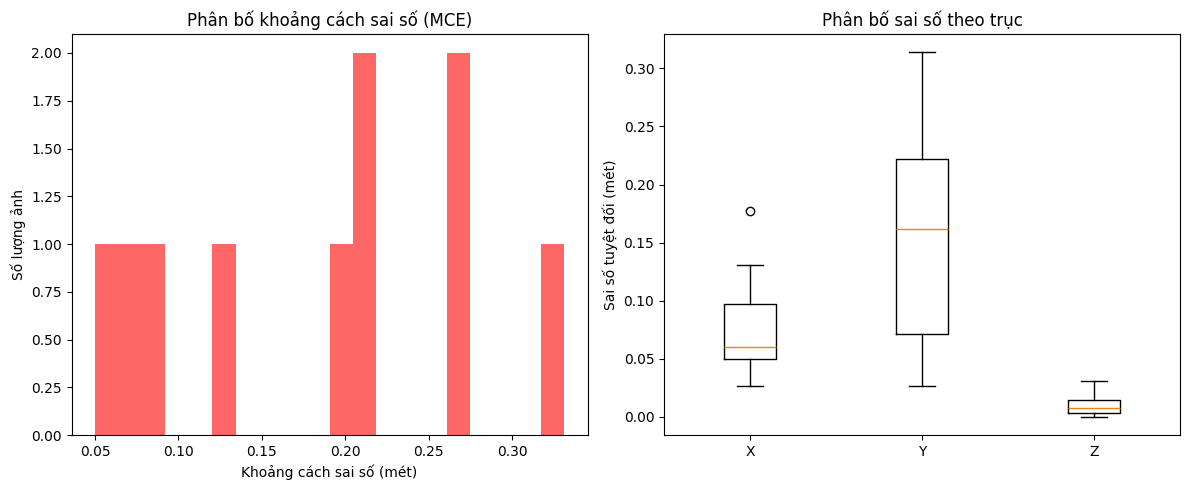

In [15]:
def analyze_worst_cases(metrics_file="comparison_metrics_normalized.csv"):
    try:
        # Đọc file metrics
        df = pd.read_csv(metrics_file)
        
        # Lọc các trường hợp có MCE = 1
        worst_cases = df[df['normalized_mce'] >= 0.99].copy()
        
        if worst_cases.empty:
            print("Không có trường hợp nào có MCE = 1!")
            return
            
        # Sắp xếp theo mce_distance để xem các trường hợp tệ nhất trước
        worst_cases = worst_cases.sort_values('mce_distance', ascending=False)
        
        print(f"\n{'='*70}")
        print(f"PHÂN TÍCH {len(worst_cases)} TRƯỜNG HỢP CÓ MCE = 1")
        print(f"{'='*70}")
        
        # Thống kê phân bố sai số theo trục
        print("\n1. Phân bố sai số tuyệt đối trung bình theo trục:")
        print(f"X: {worst_cases['x_error'].abs().mean():.3f} mét")
        print(f"Y: {worst_cases['y_error'].abs().mean():.3f} mét")
        print(f"Z: {worst_cases['z_error'].abs().mean():.3f} mét")
        
        # Thống kê khoảng cách sai số
        print("\n2. Thống kê khoảng cách sai số (MCE):")
        print(f"Nhỏ nhất: {worst_cases['mce_distance'].min():.3f} mét")
        print(f"Lớn nhất: {worst_cases['mce_distance'].max():.3f} mét")
        print(f"Trung bình: {worst_cases['mce_distance'].mean():.3f} mét")
        
        # In ra 10 trường hợp tệ nhất
        print("\n3. Top 10 trường hợp có sai số lớn nhất:")
        print("\nImage Filename      │ MCE (m) │   X_err │   Y_err │   Z_err │")
        print("─"*60)
        
        for _, row in worst_cases.head(10).iterrows():
            print(f"{row['image_filename']:.<17} │ {row['mce_distance']:7.3f} │ {row['x_error']:7.3f} │ {row['y_error']:7.3f} │ {row['z_error']:7.3f} │")
            
        # Vẽ histogram phân bố sai số
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.hist(worst_cases['mce_distance'], bins=20, color='red', alpha=0.6)
        plt.title('Phân bố khoảng cách sai số (MCE)')
        plt.xlabel('Khoảng cách sai số (mét)')
        plt.ylabel('Số lượng ảnh')
        
        plt.subplot(1, 2, 2)
        errors = [worst_cases['x_error'].abs(), 
                 worst_cases['y_error'].abs(), 
                 worst_cases['z_error'].abs()]
        plt.boxplot(errors, labels=['X', 'Y', 'Z'])
        plt.title('Phân bố sai số theo trục')
        plt.ylabel('Sai số tuyệt đối (mét)')
        
        plt.tight_layout()
        plt.show()
        
        return worst_cases
        
    except FileNotFoundError:
        print(f"Không tìm thấy file: {metrics_file}")
    except Exception as e:
        print(f"Lỗi: {e}")

# Chạy phân tích
worst_cases_df = analyze_worst_cases()

In [16]:
import numpy as np
import cv2

def map_depth_to_color_3d(depth_img, color_img, depth_intr, color_intr):

    # Chuẩn bị lưới pixel depth (giữ float32 để độ chính xác subpixel)
    h, w = depth_img.shape
    u, v = np.meshgrid(np.arange(w, dtype=np.float32),
                      np.arange(h, dtype=np.float32))

    # Chuyển depth sang mét và lọc giá trị không hợp lệ
    Z = depth_img.astype(np.float32) / 1000.0
    valid = (Z > 0.01) & (Z < 5.0) & np.isfinite(Z)

    # Không có biến dạng - dùng công thức chuẩn
    X = (u - depth_intr['cx']) * Z / depth_intr['fx']
    Y = (v - depth_intr['cy']) * Z / depth_intr['fy']

    # Tạo mảng điểm depth (meters) và lọc giá trị không hợp lệ
    points_depth = np.stack((X, Y, Z), axis=-1).reshape(-1, 3)
    valid_flat = valid.reshape(-1)
    points_depth_valid = points_depth[valid_flat]

    if len(points_depth_valid) == 0:
        return np.array([]), np.array([])

    # Biến đổi sang hệ color: p_c = R @ p_d + t
    #points_color = (R_depth_to_color @ points_depth_valid.T).T + t_depth_to_color.reshape(1, 3)

    # Chiếu sang ảnh color (giữ tọa độ float để lấy mẫu subpixel)
    Xc, Yc, Zc = points_depth_valid[:, 0], points_depth_valid[:, 1], points_depth_valid[:, 2]
    valid_z = Zc > 1e-6
    points = points_depth_valid[valid_z]

    # Chiếu với hiệu chỉnh biến dạng nếu camera màu có hệ số biến dạng
    if 'coeffs' in color_intr and np.any(np.abs(np.array(color_intr['coeffs'])) > 1e-8):
        # Tọa độ chuẩn hóa
        xn_c = Xc[valid_z] / Zc[valid_z]
        yn_c = Yc[valid_z] / Zc[valid_z]
        # Áp dụng biến dạng Brown-Conrady (forward)
        r2 = xn_c * xn_c + yn_c * yn_c
        k1, k2, p1, p2, k3 = color_intr['coeffs']
        radial = 1 + k1 * r2 + k2 * r2 * r2 + k3 * r2 * r2 * r2
        xd = xn_c * radial + 2 * p1 * xn_c * yn_c + p2 * (r2 + 2 * xn_c * xn_c)
        yd = yn_c * radial + p1 * (r2 + 2 * yn_c * yn_c) + 2 * p2 * xn_c * yn_c
        # Chiếu sang pixel
        u = xd * color_intr['fx'] + color_intr['cx']
        v= yd * color_intr['fy'] + color_intr['cy']
    else:
        # Không có biến dạng - chiếu trực tiếp
        u = Xc[valid_z] * color_intr['fx'] / Zc[valid_z] + color_intr['cx']
        v = Yc[valid_z] * color_intr['fy'] / Zc[valid_z] + color_intr['cy']

    h, w = color_img.shape[:2]
    u = np.round(u).astype(int)
    v = np.round(v).astype(int)

    # Lọc những điểm nằm trong ảnh
    in_bounds = (u >= 0) & (u < w) & (v >= 0) & (v < h)
    u = u[in_bounds]
    v = v[in_bounds]
    points = points[in_bounds]

    # Lấy màu trực tiếp (nearest neighbor)
    colors = color_img[v, u][:, ::-1] / 255.0  # BGR -> RGB

    return points, colors

In [17]:
import json
import open3d as o3d
df = pd.read_csv("Submission_3D.csv")  # CSV mày lưu kết quả với normal_plane, d_plane, selected points
dfgt = pd.read_csv("public_train.csv")
# Ví dụ chỉ lấy 1 ảnh
image_name = "image_0347.png"
row = df[df['image_filename'] == image_name].iloc[0]
row_gt = dfgt[dfgt['image_filename'] == image_name].iloc[0]
depth_path = "train/depth"
color_path = "train/rgb"
depth = cv2.imread(os.path.join(depth_path, image_name.split('_')[1]), cv2.IMREAD_UNCHANGED)
color_image_name = image_name.split('_')[1].replace(".png", ".jpg")
img = cv2.imread(os.path.join(color_path, color_image_name), cv2.IMREAD_UNCHANGED)


points_full, colors_full = map_depth_to_color_3d(depth, img, depth_intrinsics, color_intrinsics)
# Centroid 3D
pred = np.array([row['x'], row['y'], row['z']])
gt = np.array([row_gt['x'], row_gt['y'], row_gt['z']])
# Normal plane
normal = np.array(eval(row['normal_plane']))  # nếu mày lưu dưới dạng string, convert lại np.array

# d_plane
d_plane = float(row['d_plane'])

# Selected points
selected_pts = np.array(json.loads(row['selected points']))  # nếu lưu dạng string

# --- Visualization ---

# 1. Point cloud toàn ảnh
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_full)
pcd.colors = o3d.utility.Vector3dVector(colors_full)

# 2. Sphere tại centroid
sphere = o3d.geometry.TriangleMesh.create_sphere(radius=0.01)
sphere.translate(pred)
sphere.paint_uniform_color([1, 0, 0])  # Red

sphere2 = o3d.geometry.TriangleMesh.create_sphere(radius=0.01)
sphere2.translate(gt)
sphere2.paint_uniform_color([0, 1, 0])  # Green

# 3. Sphere hoặc point cloud tại selected points
pcd_inliers = o3d.geometry.PointCloud()
pcd_inliers.points = o3d.utility.Vector3dVector(selected_pts)
pcd_inliers.paint_uniform_color([0, 0, 1])  #Blue

# 4. Plane visualization (mặt phẳng nhỏ quanh centroid)
plane_size = 0.05  # mấy mét
n = normal / np.linalg.norm(normal)
# tạo 2 vector orthonormal trên plane
arbitrary = np.array([1,0,0])
if abs(np.dot(arbitrary, n)) > 0.9:
    arbitrary = np.array([0,1,0])
u = np.cross(n, arbitrary)
u /= np.linalg.norm(u)
v = np.cross(n, u)



# 5. Coordinate frame
coord_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1)

# --- Draw ---
o3d.visualization.draw_geometries([pcd,sphere, sphere2, pcd_inliers, coord_frame],
                                  window_name=f"Visualization {image_name}")